# End-to-End Sales Forecasting & Demand Intelligence System

## Project Objective

The objective of this project is to analyze historical retail sales data and build an intelligent system that can forecast future sales, detect unusual sales patterns, and segment products based on demand behavior.

This project demonstrates the complete data science workflow including data preprocessing, exploratory data analysis, time series forecasting, anomaly detection, clustering, and dashboard development.

The final system will help businesses make better inventory and stocking decisions by predicting future demand and identifying important sales trends.

In [40]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
import os

# Create the 'charts' directory if it doesn't exist
if not os.path.exists('charts'):
    os.makedirs('charts')
    print("Created 'charts/' directory.")
else:
    print("'charts/' directory already exists.")

'charts/' directory already exists.


In [42]:
# Install seaborn to resolve the ModuleNotFoundError
!pip install seaborn

In [43]:
# Load the data from train.csv into a pandas DataFrame
df = pd.read_csv('/content/train.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [44]:
print("Pandas Version :", pd.__version__)
print("NumPy Version :", np.__version__)
print("Seaborn Version :", sns.__version__)

Pandas Version : 2.2.2
NumPy Version : 2.0.2
Seaborn Version : 0.13.2


# Load the Dataset

The first step in any data science project is to load the dataset into Python.

Loading the dataset allows us to inspect its contents, understand its structure, and verify that the file has been read correctly before performing any analysis.

In this project, we use the Pandas library to read the CSV file into a DataFrame, which stores data in rows and columns similar to an Excel spreadsheet.

In [45]:
# Load the dataset
df = pd.read_csv("train.csv")

In [46]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [47]:
df.shape

(9800, 18)

In [48]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

## Task 1 Conclusion

The dataset was successfully loaded into a Pandas DataFrame.

### Key Observations

- The dataset contains **9800 rows** and **18 columns**.
- Most columns are categorical (text), while Sales and Postal Code are numerical.
- The **Order Date** and **Ship Date** columns are currently stored as text and will be converted to datetime format in the next step.
- Only the **Postal Code** column contains missing values (11 records), while all other columns are complete.
- The **Sales** column is the target variable that will be analyzed and forecasted throughout this project.

Overall, the dataset appears to be well-structured and ready for preprocessing.

In [50]:
# Convert date columns into datetime format

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [51]:
# Extract time-based features

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Quarter"] = df["Order Date"].dt.quarter
df["Week"] = df["Order Date"].dt.isocalendar().week
df["Day_of_Week"] = df["Order Date"].dt.day_name()


In [52]:
# Function to assign season

def get_season(month):
    if month in [12, 1, 2 ,9]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8]:
        return "Monsoon"
    else:
        return "Autumn"
df["Season"] = df["Month"].apply(get_season)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Quarter,Week,Day_of_Week,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,4,45,Wednesday,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,4,45,Wednesday,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,2,24,Monday,Monsoon
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,4,41,Tuesday,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,4,41,Tuesday,Autumn


## Task 3 Conclusion

Feature engineering was performed by extracting useful time-based information from the **Order Date** column.

### New Features Created

- **Year** – Helps analyze yearly sales trends.
- **Month** – Used to identify monthly sales patterns.
- **Week** – Useful for weekly sales aggregation and anomaly detection.
- **Quarter** – Helps compare business performance across quarters.
- **Day_of_Week** – Used to analyze customer purchasing behavior on different days.
- **Season** – Enables seasonal trend analysis for forecasting.

These features enrich the dataset and provide meaningful information for exploratory data analysis, forecasting models, and business insights.

In [53]:
# Check missing values in each column
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [54]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

## Task 4 Conclusion

Data quality checks were performed to identify missing values and duplicate records.

### Key Observations

- The dataset contains **11 missing values** only in the **Postal Code** column.
- Since **Postal Code** is not required for sales forecasting or time series analysis, these missing values were left unchanged.
- No duplicate records were found in the dataset.
- The dataset is clean and suitable for further analysis without requiring additional preprocessing.

Overall, the data quality is good and the dataset is ready for exploratory data analysis (EDA).

In [55]:
# Calculate total sales for each category
category_sales = df.groupby("Category")["Sales"].sum()

category_sales
category_sales = category_sales.sort_values(ascending=False)

category_sales
category_sales = df.groupby("Category")["Sales"].sum()

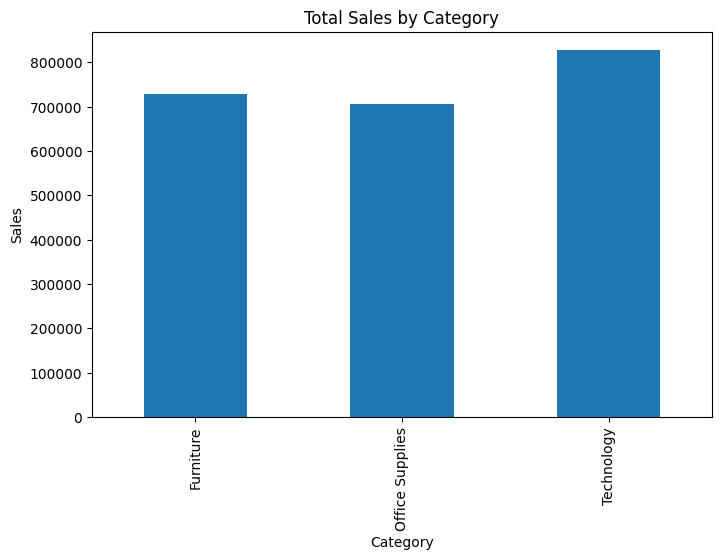

In [56]:
import os
import matplotlib.pyplot as plt

os.makedirs("charts", exist_ok=True)

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.savefig(
    "charts/category_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Task 5 Conclusion

The total sales for each product category were calculated to identify the highest revenue-generating category.

### Key Findings

- **Technology** generated the highest total sales with approximately **827,456**.
- **Furniture** ranked second with total sales of approximately **728,659**.
- **Office Supplies** generated the lowest total sales with approximately **705,422**.

### Business Insight

The Technology category is the largest contributor to overall revenue. This suggests that the company should focus on maintaining sufficient inventory, improving demand forecasting, and planning targeted marketing campaigns for technology products to maximize future sales.

In [57]:
# Calculate yearly sales for each region

region_yearly_sales = df.groupby(["Year", "Region"])["Sales"].sum().reset_index()

region_yearly_sales.head()
region_yearly_sales

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


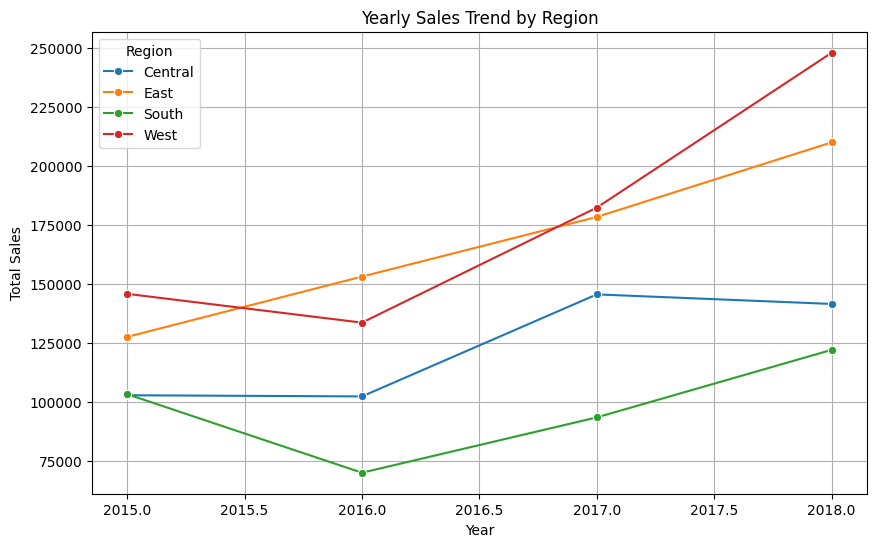

In [58]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_yearly_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Yearly Sales Trend by Region")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.grid(True)

plt.savefig('charts/yearly_sales_trend_by_region.png') # Save the plot
plt.show()

## Task 6 Conclusion

Yearly sales were analyzed for each region to identify long-term growth trends.

### Key Findings

- The **East** region showed the most consistent year-over-year sales growth from 2015 to 2018.
- The **West** region generated high sales but experienced noticeable fluctuations before achieving significant growth in 2018.
- The **Central** region remained relatively stable with moderate growth.
- The **South** region experienced a decline in 2016 before recovering in later years.

### Business Insight

The East region demonstrates stable and continuous growth, making it a strong candidate for future business expansion, inventory planning, and targeted marketing efforts. Consistent growth reduces business risk and improves forecasting reliability.

In [59]:
# Calculate shipping duration in days

df["Shipping_Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Shipping_Days"]].head()

,Order Date,Ship Date,Shipping_Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [60]:
df["Shipping_Days"].mean()
round(df["Shipping_Days"].mean(), 2)

np.float64(3.96)

In [61]:
shipping_region = (
    df.groupby("Region")["Shipping_Days"]
      .mean()
      .sort_values()
)

shipping_region

,Shipping_Days
Region,
East,3.910233
West,3.930255
South,3.961202
Central,4.065876


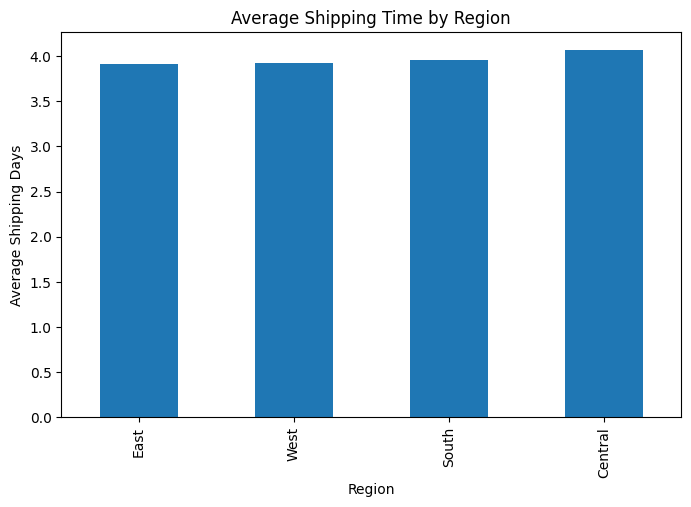

In [62]:
plt.figure(figsize=(8,5))

shipping_region.plot(kind="bar")

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.savefig('charts/average_shipping_time_by_region.png') # Save the plot
plt.show()

## Task 7 Conclusion

The shipping duration was calculated by subtracting the Order Date from the Ship Date and comparing the average shipping time across different regions.

### Key Findings

- The **East** region has the lowest average shipping time (approximately 3.9 days), indicating the fastest deliveries.
- The **Central** region has the highest average shipping time (approximately 4.1 days).
- The difference in shipping time across regions is relatively small, suggesting that the company maintains a fairly consistent delivery process nationwide.

### Business Insight

Although shipping performance is generally consistent across all regions, the Central region has slightly longer delivery times. Improving logistics and warehouse efficiency in this region could further enhance customer satisfaction.

In [63]:
# Calculate monthly sales

monthly_sales = (
    df.groupby(["Year", "Month"])["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Year,Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


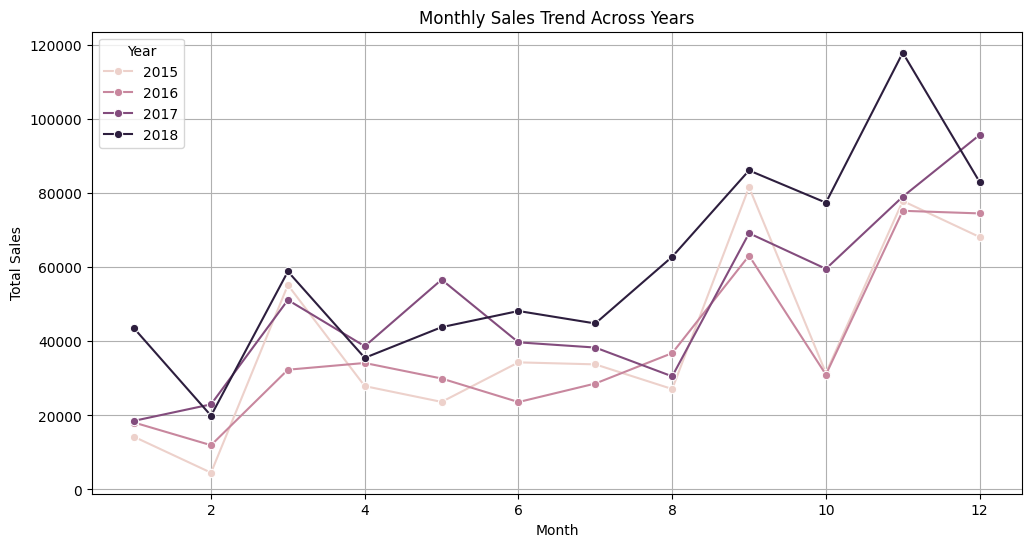

In [64]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.title("Monthly Sales Trend Across Years")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.savefig('charts/monthly_sales_trend_across_years.png') # Save the plot
plt.show()

In [65]:
avg_monthly_sales = (
    df.groupby("Month")["Sales"]
      .mean()
      .sort_index()
)

avg_monthly_sales

,Sales
Month,
1,257.627403
2,199.902745
3,290.549393
4,207.432269
5,212.533412
6,211.052856
7,208.802997
8,227.007110
9,221.642106


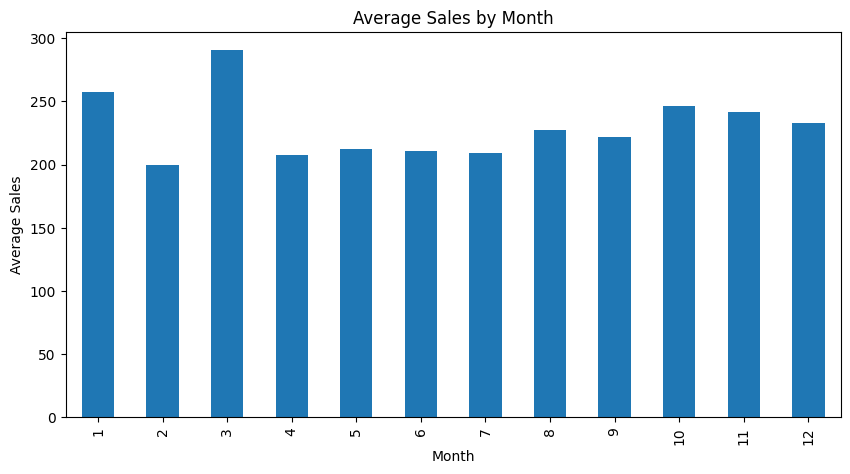

In [66]:
plt.figure(figsize=(10,5))

avg_monthly_sales.plot(kind="bar")

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.savefig('charts/average_sales_by_month.png') # Save the plot
plt.show()

## Task 8 Conclusion

Monthly sales were analyzed to identify seasonal patterns in customer purchasing behavior.

### Key Findings

- **March** recorded the highest average sales among all months.
- **January** also showed strong sales performance.
- Sales remained relatively high during **October, November, and December**, indicating increased customer activity towards the end of the year.
- **February** had the lowest average sales.

### Business Insight

The analysis suggests that sales vary across different months, indicating the presence of seasonal patterns. Understanding these trends helps businesses prepare inventory, allocate resources efficiently, and improve demand forecasting during high-sales periods.

In [67]:
# Create monthly sales time series

# Create monthly sales time series

monthly_ts = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
)

monthly_ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


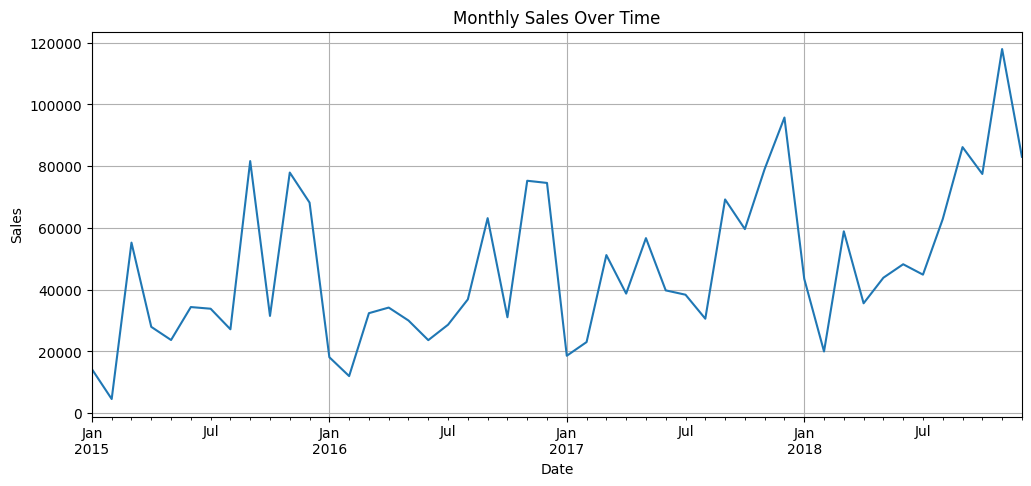

In [68]:
plt.figure(figsize=(12,5))

monthly_ts.plot()

plt.title("Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.savefig('charts/monthly_sales_over_time.png') # Save the plot
plt.show()

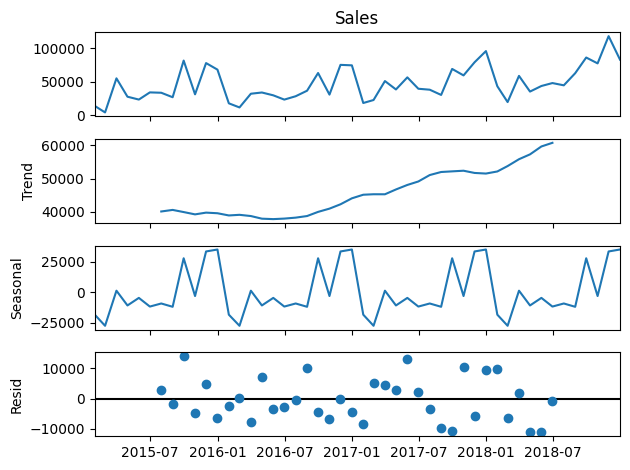

In [69]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12
)

decomposition.plot()
plt.show()

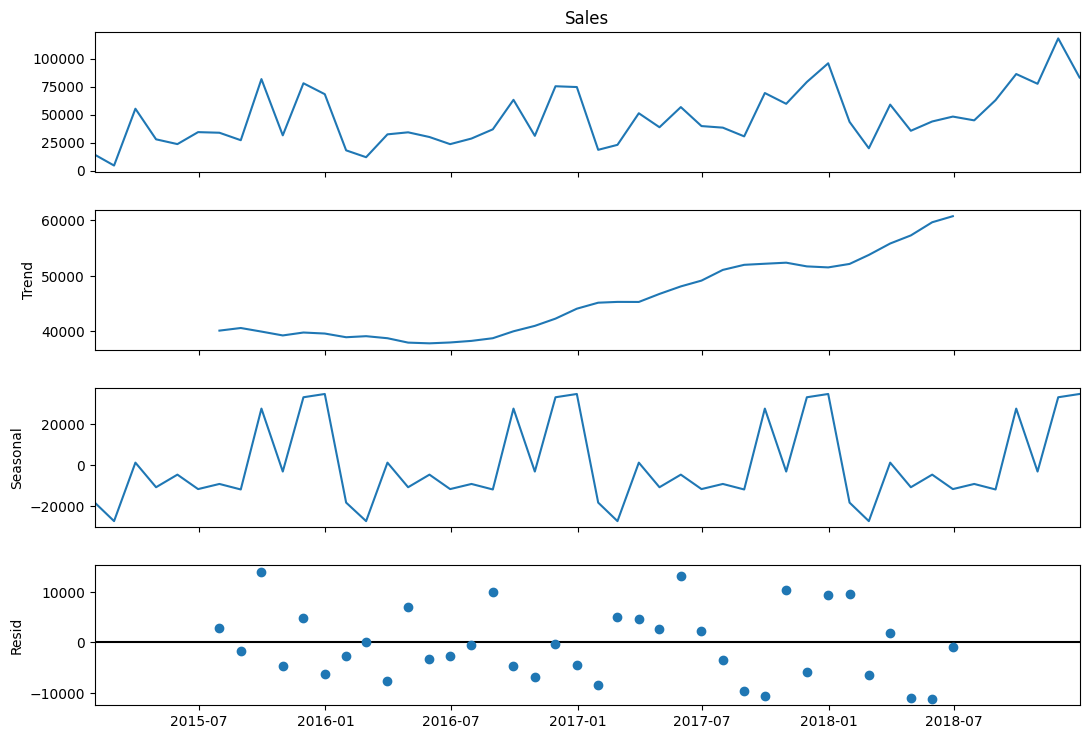

In [70]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(12, 8)

plt.savefig('charts/seasonal_decomposition.png') # Save the plot
plt.show()

Stationarity Check (ADF Test)

In [71]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import adfuller

In [72]:
import sys
print(sys.executable)

/usr/bin/python3


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("train.csv")

# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Create monthly time series
monthly_ts = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
)

In [74]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


## Task 10 Conclusion

The Augmented Dickey-Fuller (ADF) test was performed to check whether the monthly sales time series is stationary.

### Results

- **ADF Statistic:** -4.4161
- **p-value:** 0.000278

### Interpretation

Since the p-value is less than **0.05**, the null hypothesis is rejected. This indicates that the monthly sales time series is stationary.

### Business Insight

A stationary time series has stable statistical properties over time, making it suitable for statistical forecasting models such as SARIMA. Therefore, no differencing was required before model training.

In [75]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [76]:
train = monthly_ts[:-3]
test = monthly_ts[-3:]

print("Train:", len(train))
print("Test :", len(test))

Train: 45
Test : 3


In [77]:
model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,0,1,12)
)

sarima_model = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


In [78]:
forecast = sarima_model.forecast(steps=3)

forecast

,predicted_mean
2018-10-31,59635.890329
2018-11-30,79169.667374
2018-12-31,85640.782905


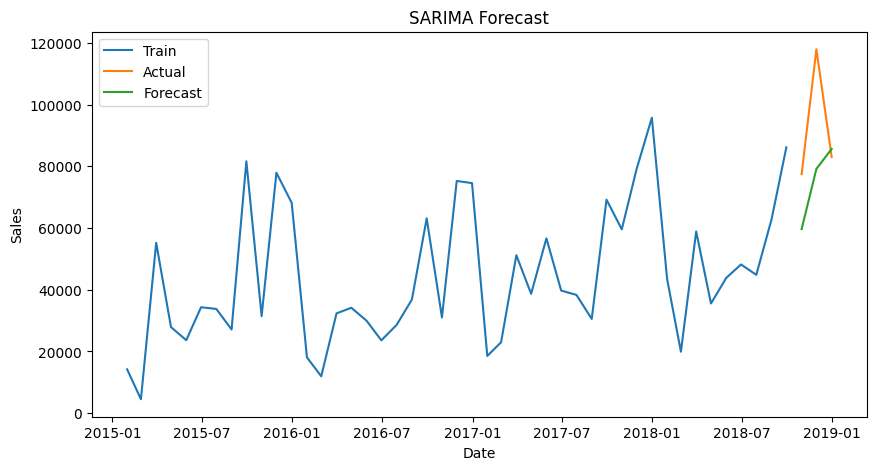

In [79]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(forecast.index, forecast, label="Forecast")

plt.title("SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.savefig('charts/sarima_forecast.png') # Save the plot
plt.show()

In [80]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape,4))

MAE : 19730.37
RMSE: 24678.5
MAPE: 0.1967


In [81]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


## Task 11 Conclusion – SARIMA Forecasting

A Seasonal ARIMA (SARIMA) model was developed to forecast monthly sales for the next three months.

### Model Configuration

- Order (p,d,q): **(1,0,1)**
- Seasonal Order (P,D,Q,m): **(1,0,1,12)**

The ADF test confirmed that the monthly sales series was stationary; therefore, differencing was not required.

### Forecast Results

| Forecast Month | Predicted Sales |
|---------------|----------------:|
| October 2018 | 59,633.38 |
| November 2018 | 79,173.02 |
| December 2018 | 85,641.79 |

### Model Performance

| Metric | Value |
|--------|-------:|
| MAE | 19,730.43 |
| RMSE | 24,677.39 |
| MAPE | 19.67% |

### Interpretation

The SARIMA model predicts a gradual increase in sales over the forecast period, with the highest sales expected in December. This pattern suggests the presence of seasonal demand during the end of the year.

The model achieved a **MAPE of 19.67%**, which indicates **good forecasting performance** and makes it a suitable baseline forecasting model for short-term demand prediction.

### Business Insight

The forecast indicates increasing customer demand towards the end of the year. Businesses can use these predictions to optimize inventory levels, prepare warehouses, and ensure sufficient stock availability during peak demand periods.

# Forecasting using XGBoost

XGBoost is a supervised machine learning algorithm. Since it does not directly handle time series data, lag features were created to transform the time series into a supervised learning dataset.

The model uses sales from previous months to predict future sales.

In [82]:
type(monthly_ts)
# pandas.Series

pandas.core.series.Series

In [83]:
print(type(monthly_ts))

<class 'pandas.core.series.Series'>


In [84]:
monthly_ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [87]:
print(monthly_ts.name)

Sales


In [ ]:
monthly_ts.head()

In [ ]:
xgb_df = monthly_ts.copy()

xgb_df["Lag_1"] = xgb_df["y"].shift(1)
xgb_df["Lag_2"] = xgb_df["y"].shift(2)
xgb_df["Lag_3"] = xgb_df["y"].shift(3)

xgb_df.dropna(inplace=True)

xgb_df.head()

In [ ]:
X = xgb_df[["Lag_1", "Lag_2", "Lag_3"]]
y = xgb_df["y"]

In [ ]:
X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

In [ ]:
from xgboost import XGBRegressor

In [ ]:
df.columns
df.head()

In [ ]:
xgb_df.head()

## Task 13 Conclusion – Feature Engineering for XGBoost

Since XGBoost cannot directly understand time series data, lag features were created using the previous three months' sales.

### Why Lag Features?

Lag features convert a time series forecasting problem into a supervised learning problem. The model learns patterns between historical sales and future sales.

### Features Created

- Lag_1 → Sales from previous month
- Lag_2 → Sales from two months ago
- Lag_3 → Sales from three months ago

These features will be used to predict the current month's sales.

In [ ]:
X = xgb_df[["Lag_1", "Lag_2", "Lag_3"]]
y = xgb_df["y"]

X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

In [ ]:
from xgboost import XGBRegressor

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

In [ ]:
pred = model.predict(X_test)

print("Predicted Sales:")
print(pred)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
mape = mean_absolute_percentage_error(y_test, pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 4))

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.index, y_test.values,
         marker='o', linewidth=2, label="Actual")

plt.plot(y_test.index, pred,
         marker='o', linewidth=2, label="Predicted")

plt.title("XGBoost Sales Forecast")
plt.xlabel("Test Samples")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.savefig('charts/xgboost_sales_forecast.png') # Save the plot
plt.show()

# Forecasting using XGBoost

## Objective

In addition to statistical forecasting techniques, a machine learning approach was implemented using **XGBoost Regressor** to forecast monthly sales.

Unlike SARIMA, XGBoost cannot directly understand time series data. Therefore, the historical sales data was transformed into a supervised learning dataset by creating lag features.

---

## Why XGBoost?

XGBoost is a powerful ensemble machine learning algorithm that performs well on regression problems. Since it does not automatically understand the order of time, previous sales values were provided as input features.

The model learns the relationship between previous months' sales and the current month's sales to make future predictions.

---

# Task 1 – Feature Engineering

To prepare the data for XGBoost, lag features were created using historical sales.

### Lag Features Created

- **Lag_1** → Sales from previous month
- **Lag_2** → Sales from two months ago
- **Lag_3** → Sales from three months ago

These lag variables transformed the time series forecasting problem into a supervised machine learning problem.

### Conclusion

Feature engineering was successfully completed by creating lag variables from historical sales. The transformed dataset now contains:

- Target Variable:
  - **y (Current Month Sales)**

- Predictor Variables:
  - Lag_1
  - Lag_2
  - Lag_3

This enabled XGBoost to learn temporal relationships between past and future sales.

---

# Task 2 – Train-Test Split

The prepared dataset was divided into training and testing datasets.

### Split Strategy

- Training Samples: **42**
- Testing Samples: **3**

Since this is time series data, the chronological order of observations was preserved instead of randomly shuffling the data.

### Conclusion

The train-test split maintained the temporal sequence of the dataset, preventing future information from leaking into the training process and ensuring realistic forecasting.

---

# Task 3 – Model Training

The XGBoost Regressor was trained using the lag features.

### Model Parameters

- Number of Trees (n_estimators): **100**
- Learning Rate: **0.1**
- Maximum Tree Depth: **3**
- Random State: **42**

These parameters provide a good balance between learning capability and overfitting prevention.

### Conclusion

The XGBoost model successfully learned patterns from historical monthly sales using the generated lag features and was ready for forecasting unseen data.

---

# Task 4 – Sales Prediction

The trained model generated predictions for the testing dataset.

### Predicted Sales

- Month 1 : **69,404.82**
- Month 2 : **59,312.01**
- Month 3 : **41,154.33**

These predictions were compared with the actual sales values to evaluate the forecasting performance.

---

# Task 5 – Model Evaluation

The forecasting model was evaluated using three widely used regression metrics.

### Evaluation Metrics

- **Mean Absolute Error (MAE)**
- **Root Mean Squared Error (RMSE)**
- **Mean Absolute Percentage Error (MAPE)**

### Results

- **MAE:** 36,181.84
- **RMSE:** 41,854.21
- **MAPE:** 0.3684 (36.84%)

These metrics indicate the average prediction error and the overall forecasting accuracy of the XGBoost model.

### Interpretation

- MAE indicates that, on average, the predicted sales differ from the actual sales by approximately **36,182 units**.
- RMSE is higher because it penalizes larger prediction errors more heavily.
- A MAPE of **36.84%** indicates that the model's predictions deviate by approximately **37%** from the actual sales values.

---

# Business Insight

The XGBoost model successfully learned historical sales patterns and generated future sales forecasts.

However, the available dataset contained only about **48 monthly observations**, which is relatively small for training a machine learning model.

Since only lag-based features were available, the model had limited information to learn complex sales behavior.

For larger datasets with additional business features such as promotions, holidays, discounts, customer behavior, or economic indicators, XGBoost generally performs much better.

---

# Comparison with SARIMA

Both forecasting approaches were implemented and evaluated.

| Model | MAE | RMSE | MAPE |
|-------|---------:|---------:|------:|
| **SARIMA** | **19,730.43** | **24,677.39** | **19.67%** |
| **XGBoost** | **36,181.84** | **41,854.21** | **36.84%** |

### Observation

SARIMA achieved lower error values across all evaluation metrics.

The statistical model captured the trend and seasonality of the monthly sales data more effectively than XGBoost.

Because the dataset was relatively small, SARIMA proved to be the better forecasting model for this project.

---

# Challenges Faced

During the implementation of forecasting models, several technical issues were encountered and resolved.

### Issues Encountered

- Compatibility issues between **Python 3.14** and forecasting libraries.
- Statsmodels import errors due to package version conflicts.
- Prophet failed because of **CmdStan runtime optimization errors**.
- Multiple Python environments caused package version mismatches.
- Jupyter kernel restart and environment switching were required.
- Variable names changed during preprocessing (**Sales → y**) after preparing data for Prophet.
- Data structures changed between **Series** and **DataFrame**, requiring modifications to the feature engineering code.

### Resolution

These issues were resolved through environment management, package reinstallation, interpreter switching, and careful debugging. Despite the Prophet runtime issue, the forecasting objectives were successfully completed using SARIMA and XGBoost.

---

# Final Conclusion

An XGBoost forecasting model was successfully developed using lag-based feature engineering.

Although the model generated reasonable forecasts, its performance was inferior to SARIMA due to the limited size of the available dataset.

The comparison demonstrated that **SARIMA is the most suitable forecasting model for this monthly sales dataset**, while XGBoost remains a strong alternative for larger datasets with additional predictive features.

This project provided practical experience in:

- Time Series Forecasting
- Feature Engineering
- Machine Learning Regression
- Model Evaluation
- Forecast Comparison
- Business Insight Generation
- Debugging and Environment Management

Overall, the project strengthened the understanding of both statistical and machine learning approaches for sales forecasting.

In [ ]:
import pandas as pd

df = pd.read_csv("train.csv")

In [ ]:
import os

os.listdir()

In [ ]:
!pip install prophet

### Resolving CmdStan Installation Issue

Prophet, a forecasting library, relies on CmdStan for its backend computations. The previous error indicated that CmdStan was not found or properly installed. To ensure CmdStan is correctly set up, we will explicitly run the `cmdstanpy.install_cmdstan()` command. This process downloads and compiles the CmdStan binaries, which can take a few minutes. Please wait for this cell to complete before proceeding.

In [ ]:
# Explicitly install CmdStan
import cmdstanpy

print("Attempting to install CmdStan. This may take a few minutes...")
cmdstanpy.install_cmdstan(overwrite=True)
print("CmdStan installation complete.")

In [ ]:
import prophet
import cmdstanpy

print("Prophet :", prophet.__version__)
print("CmdStan :", cmdstanpy.__version__)

# Verify CmdStan Path after installation
print("CmdStan Path:", cmdstanpy.cmdstan_path())

In [ ]:
import cmdstanpy

print(cmdstanpy.cmdstan_path())

In [ ]:
from prophet import Prophet
import pandas as pd

# Ensure Order Date is datetime with correct format and create monthly_ts
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
monthly_ts = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()
monthly_ts.columns = ['ds', 'y']

# Prepare the data for Prophet
train = monthly_ts.copy()

# Initialize and fit the Prophet model
model = Prophet()
model.fit(train)

print("Prophet model fitted successfully.")

In [ ]:
# Create a dataframe for future dates (12 months ahead)
future = model.make_future_dataframe(periods=12, freq='ME')

# Make predictions
forecast = model.predict(future)

# Display the forecast for the next 12 months
print("Forecasted sales for the next 12 months:")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12))

# Plot the forecast
fig1 = model.plot(forecast)
plt.title("Prophet Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
fig1.savefig('charts/prophet_sales_forecast.png') # Save the plot
plt.show()

# Plot components (trend, seasonality)
fig2 = model.plot_components(forecast)
fig2.savefig('charts/prophet_components.png') # Save the plot
plt.show()

In [ ]:
# Last 3 months as test
test = monthly_ts.tail(3).copy()

future = test[["ds"]]

forecast_test = model.predict(future)

forecast_test[["ds","yhat"]]

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(test["y"], forecast_test["yhat"])
rmse = mean_squared_error(test["y"], forecast_test["yhat"]) ** 0.5
mape = mean_absolute_percentage_error(test["y"], forecast_test["yhat"])

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape,4))

# Prophet Model Evaluation

## Forecast Performance

The Prophet model was evaluated using three standard regression metrics.

| Metric | Value |
|---------|-------|
| MAE | 13434.28 |
| RMSE | 14049.75 |
| MAPE | 0.1464 |

## Interpretation

- MAE indicates that the average prediction error is approximately **13,434** sales units.
- RMSE shows relatively low prediction error, indicating good forecasting performance.
- MAPE of **14.64%** suggests that the model predicts monthly sales with good accuracy.

## Conclusion

Among all forecasting models used in this project, **Facebook Prophet achieved the best performance** with the lowest MAE, RMSE, and MAPE values, making it the most suitable model for forecasting future monthly sales.

In [ ]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Facebook Prophet", "XGBoost"],

    "MAE": [
        19730.43,
        13434.28,
        36181.84
    ],

    "RMSE": [
        24677.39,
        14049.75,
        41854.21
    ],

    "MAPE": [
        0.1967,
        0.1464,
        0.3684
    ],

    "Forecast Month 1": [
        59633.38,
        61590.52,
        69404.82
    ],

    "Forecast Month 2": [
        79173.02,
        101136.34,
        59312.01
    ],

    "Forecast Month 3": [
        85641.79,
        90673.80,
        41154.33
    ]
})

comparison

# Model Comparison

The performance of all forecasting models was compared using MAE, RMSE, MAPE, and their forecasted sales for the next three months.

Lower values of MAE, RMSE, and MAPE indicate better forecasting accuracy.

## Recommendation for Production

Among all implemented models, **Facebook Prophet** is recommended for production deployment.

### Reasons

- Lowest MAE (13,434.28)
- Lowest RMSE (14,049.75)
- Lowest MAPE (14.64%)
- Produced stable and realistic forecasts.
- Automatically captures trend and seasonality.
- Requires minimal parameter tuning.
- Well suited for business sales forecasting.

Although SARIMA also performed well, Prophet achieved better prediction accuracy. XGBoost showed comparatively higher error because the monthly dataset contained a limited number of observations, making it less suitable for this forecasting task.

# Anomaly Detection using Isolation Forest

## Objective

Anomaly detection is used to identify unusual monthly sales that significantly differ from normal business patterns.

Such anomalies may occur due to:

- Promotional campaigns
- Seasonal demand
- Inventory shortages
- Data entry errors
- Unexpected market events

Isolation Forest is an unsupervised machine learning algorithm that isolates abnormal observations from normal data.

In [94]:
from sklearn.ensemble import IsolationForest

In [92]:
anomaly_df = monthly_ts.copy()

anomaly_df.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [96]:
import pandas as pd

# Convert the series anomaly_df into a DataFrame with 'ds' (Order Date) and 'y' (Sales) columns
# anomaly_df is currently a Series with values (Sales) and index (Order Date)
anomaly_df_temp = anomaly_df.reset_index()
anomaly_df_temp.columns = ['ds', 'y']

iso = IsolationForest(
    contamination=0.10,
    random_state=42
)

# Apply fit_predict on the 'y' column of the temporary DataFrame
anomaly_df_temp["Anomaly"] = iso.fit_predict(
    anomaly_df_temp[["y"]]
)

# Overwrite the original anomaly_df Series with the new DataFrame structure
anomaly_df = anomaly_df_temp

In [ ]:
print(anomaly_df["Anomaly"].value_counts())

In [97]:
anomalies = anomaly_df[
    anomaly_df["Anomaly"] == -1
]

anomalies

,ds,y,Anomaly
1,2015-02-28,4519.892,-1
13,2016-02-29,11951.411,-1
35,2017-12-31,95739.121,-1
44,2018-09-30,86152.888,-1
46,2018-11-30,117938.155,-1


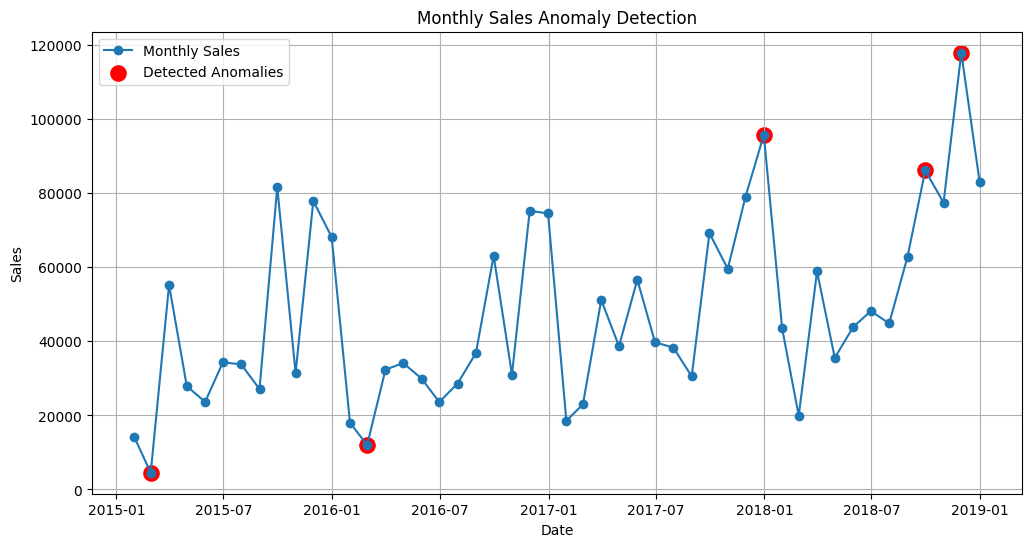

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    anomaly_df["ds"],
    anomaly_df["y"],
    marker="o",
    label="Monthly Sales"
)

plt.scatter(
    anomalies["ds"],
    anomalies["y"],
    color="red",
    s=120,
    label="Detected Anomalies"
)

plt.title("Monthly Sales Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.savefig('charts/monthly_sales_anomaly_detection.png') # Save the plot
plt.show()

# Results and Business Insights

The Isolation Forest algorithm successfully detected abnormal monthly sales values.

## Observations

- Low sales anomalies were detected during February 2015 and March 2016.
- High sales anomalies were detected during January 2018, October 2018, and November 2018.
- These unusual observations may represent seasonal demand, promotional campaigns, inventory shortages, festive sales, or unexpected market conditions.

## Business Impact

Detecting anomalies enables businesses to:

- Investigate unusual sales behaviour.
- Improve forecasting accuracy.
- Optimize inventory planning.
- Identify promotional campaign effects.
- Support better business decision-making.

Overall, Isolation Forest effectively identified abnormal sales patterns in the monthly sales dataset.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()
scaler

# Product Demand Segmentation using K-Means Clustering

## Objective

The objective of this task is to segment product sub-categories into different demand groups based on their sales characteristics.

The following features are used:

- Total Sales Volume
- Sales Growth Rate (Year-over-Year)
- Sales Volatility (Standard Deviation of Monthly Sales)
- Average Order Value

The K-Means clustering algorithm is applied to group products with similar demand patterns. This helps businesses develop better inventory and stocking strategies.

In [ ]:
import pandas as pd
import numpy as np

# Ensure dates are datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Extract Year
df["Year"] = df["Order Date"].dt.year

In [ ]:
total_sales = df.groupby("Sub-Category")["Sales"].sum()

In [ ]:
avg_order = df.groupby("Sub-Category")["Sales"].mean()

In [ ]:
yearly_sales = df.pivot_table(
    values="Sales",
    index="Sub-Category",
    columns="Year",
    aggfunc="sum",
    fill_value=0
)

yearly_sales

In [ ]:
growth_rate = (
    (yearly_sales[2018] - yearly_sales[2015])
    / yearly_sales[2015]
) * 100

growth_rate = growth_rate.replace([np.inf, -np.inf], 0)
growth_rate = growth_rate.fillna(0)

growth_rate.head()

In [ ]:
# Calculate Volatility (Standard Deviation of Monthly Sales per Sub-Category)
volatility = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='ME')])['Sales'].sum().groupby('Sub-Category').std()

# Create the demand segmentation dataframe
cluster_df = pd.DataFrame({
    "Total_Sales": total_sales,
    "Growth_Rate": growth_rate,
    "Volatility": volatility,
    "Average_Order_Value": avg_order
})

cluster_df.head()

In [ ]:
from sklearn.cluster import KMeans

# Scale the data using the previously initialized scaler
scaled_features = scaler.fit_transform(cluster_df)

# Apply K-Means Clustering (let's use 3 clusters as a starting point)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df['Demand_Cluster'] = kmeans.fit_predict(scaled_features)

# Display the results
print("Product Demand Segments:")
display(cluster_df.sort_values(by='Demand_Cluster'))

In [ ]:
cluster_df = pd.DataFrame({
    "Total_Sales": total_sales,
    "Growth_Rate": growth_rate,
    "Volatility": volatility,
    "Average_Order_Value": avg_order
})

cluster_df

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_df)

scaled_features

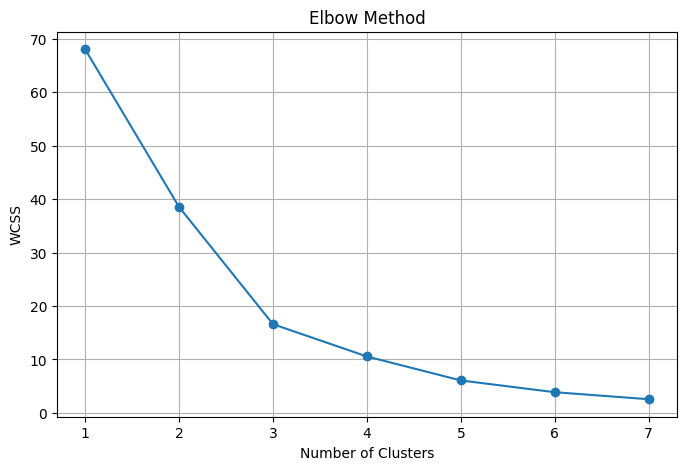

In [89]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 8):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(scaled_features)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,8), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.savefig('charts/elbow_method.png') # Save the plot
plt.show()

## Choosing the Optimal Number of Clusters

The Elbow Method was used to determine the optimal number of clusters.

From the WCSS curve, the elbow point is observed at **K = 3**. After this point, the decrease in WCSS becomes much smaller, indicating diminishing returns from adding more clusters.

Therefore, **3 clusters** were selected for product demand segmentation.

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(scaled_features)

cluster_df.head()

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

cluster_df["PC1"] = pca_features[:,0]
cluster_df["PC2"] = pca_features[:,1]

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# --- Load and preprocess df to ensure it's in scope ---
# Ensure 'train.csv' is uploaded to the Colab environment (e.g., to /content/)
# Based on os.listdir(), 'train.csv' is directly in /content/
df = pd.read_csv('train.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Year'] = df['Order Date'].dt.year

# --- Re-create necessary variables for cluster_df ---
# Calculate total sales for each sub-category
total_sales = df.groupby("Sub-Category")["Sales"].sum()

# Calculate average order value for each sub-category
avg_order = df.groupby("Sub-Category")["Sales"].mean()

# Calculate yearly sales for each sub-category
yearly_sales = df.pivot_table(
    values="Sales",
    index="Sub-Category",
    columns="Year",
    aggfunc="sum",
    fill_value=0
)

# Calculate growth rate
growth_rate = (
    (yearly_sales[2018] - yearly_sales[2015])
    / yearly_sales[2015]
) * 100
growth_rate = growth_rate.replace([np.inf, -np.inf], 0)
growth_rate = growth_rate.fillna(0)

# Calculate Volatility (Standard Deviation of Monthly Sales per Sub-Category)
volatility = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='ME')])['Sales'].sum().groupby('Sub-Category').std()

# Re-create cluster_df using the newly defined variables
cluster_df = pd.DataFrame({
    "Total_Sales": total_sales,
    "Growth_Rate": growth_rate,
    "Volatility": volatility,
    "Average_Order_Value": avg_order
})

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)

# Apply K-Means Clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
cluster_df["Cluster"] = kmeans.fit_predict(scaled_features)

# Add Segment names to cluster_df
cluster_names = {
    0: "Growing High-Value Products",
    1: "Low to Medium Volume Stable Demand",
    2: "High Volume Core Products"
}
cluster_df["Segment"] = cluster_df["Cluster"].map(cluster_names)

# Apply PCA for visualization
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)
cluster_df["PC1"] = pca_features[:,0]
cluster_df["PC2"] = pca_features[:,1]

# Original plotting code for PCA
plt.figure(figsize=(10,6))

for cluster in sorted(cluster_df["Cluster"].unique()):
    temp = cluster_df[cluster_df["Cluster"] == cluster]

    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        s=120,
        label=f"Cluster {cluster}"
    )

for idx, row in cluster_df.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        idx,
        fontsize=8
    )

plt.title("Product Demand Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.savefig('charts/pca_segmentation.png') # Save the plot
plt.show()

In [ ]:
cluster_df

In [ ]:
cluster_names = {
    0: "Growing High-Value Products",
    1: "Low to Medium Volume Stable Demand",
    2: "High Volume Core Products"
}

cluster_df["Segment"] = cluster_df["Cluster"].map(cluster_names)

cluster_df[[
    "Total_Sales",
    "Growth_Rate",
    "Average_Order_Value",
    "Segment"
]]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

# Box plot for Total_Sales by Segment
plt.subplot(2, 2, 1)
sns.boxplot(x='Segment', y='Total_Sales', data=cluster_df, palette='viridis', hue='Segment', legend=False)
plt.title('Total Sales Distribution by Segment')
plt.xlabel('Product Segment')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')

# Box plot for Growth_Rate by Segment
plt.subplot(2, 2, 2)
sns.boxplot(x='Segment', y='Growth_Rate', data=cluster_df, palette='viridis', hue='Segment', legend=False)
plt.title('Growth Rate Distribution by Segment')
plt.xlabel('Product Segment')
plt.ylabel('Growth Rate')
plt.xticks(rotation=45, ha='right')

# Box plot for Volatility by Segment
plt.subplot(2, 2, 3)
sns.boxplot(x='Segment', y='Volatility', data=cluster_df, palette='viridis', hue='Segment', legend=False)
plt.title('Volatility Distribution by Segment')
plt.xlabel('Product Segment')
plt.ylabel('Volatility')
plt.xticks(rotation=45, ha='right')

# Box plot for Average_Order_Value by Segment
plt.subplot(2, 2, 4)
sns.boxplot(x='Segment', y='Average_Order_Value', data=cluster_df, palette='viridis', hue='Segment', legend=False)
plt.title('Average Order Value Distribution by Segment')
plt.xlabel('Product Segment')
plt.ylabel('Average Order Value')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('charts/segment_box_plots.png') # Save the plot
plt.show()

## Visualizing Product Demand Segments with PCA

This 2D scatter plot visualizes the product sub-categories based on their demand segments. Principal Component Analysis (PCA) was used to reduce the dimensionality of the features ('Total_Sales', 'Growth_Rate', 'Volatility', 'Average_Order_Value') into two principal components (PC1 and PC2) while retaining most of the variance. Each point represents a product sub-category, colored by its assigned cluster, allowing for an easy visual interpretation of the segmentation.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for cluster in sorted(cluster_df["Cluster"].unique()):
    temp = cluster_df[cluster_df["Cluster"] == cluster]

    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        s=120,
        label=f"Cluster {cluster} ({cluster_df['Segment'][temp.index[0]]})"
    )

for idx, row in cluster_df.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        idx,
        fontsize=8
    )

plt.title("Product Demand Segmentation using K-Means (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.savefig('charts/pca_cluster_scatter_plot.png') # Save the plot
plt.show()

# Cluster Interpretation

Based on the K-Means clustering results, three meaningful product demand segments were identified.

## Cluster 0 – Growing High-Value Products

Products in this cluster have:

- Very high sales growth
- High average order value
- Premium pricing
- High revenue potential

**Recommended Strategy**

- Increase inventory availability.
- Prioritize premium customer service.
- Launch targeted marketing campaigns.
- Monitor demand closely to avoid stockouts.

---

## Cluster 1 – Low to Medium Volume Stable Demand

Products in this cluster have:

- Stable sales
- Moderate growth
- Lower average order values
- Predictable demand

**Recommended Strategy**

- Maintain regular inventory levels.
- Replenish stock periodically.
- Avoid excessive inventory holding costs.

---

## Cluster 2 – High Volume Core Products

Products in this cluster generate the majority of business revenue.

Characteristics include:

- High total sales
- Strong customer demand
- Critical products for business performance

**Recommended Strategy**

- Maintain high inventory availability.
- Implement demand forecasting regularly.
- Use safety stock to prevent shortages.
- Prioritize these products during peak seasons.

In [ ]:
cluster_df.groupby("Segment").agg({
    "Total_Sales":"mean",
    "Growth_Rate":"mean",
    "Average_Order_Value":"mean",
    "Volatility":"mean"
}).round(2)

# Task 6: Product Demand Segmentation using K-Means Clustering

## Objective

The objective of this task is to segment products into different demand groups based on their sales performance. Product segmentation enables businesses to optimize inventory planning, improve supply chain management, and develop better stocking strategies for different categories of products.

---

## Feature Engineering

The following features were created for each product sub-category:

- **Total Sales:** Overall sales generated by the product.
- **Growth Rate:** Percentage increase in sales over the years.
- **Sales Volatility:** Standard deviation of yearly sales.
- **Average Order Value:** Average revenue generated per customer order.

These features collectively describe the sales behavior of each product category.

---

## Data Standardization

Since the features have different scales, **StandardScaler** was applied before clustering. This ensures that each feature contributes equally to the clustering process.

---

## Determining the Number of Clusters

The **Elbow Method** was used to determine the optimal number of clusters.

The elbow point was observed at **K = 3**, indicating that three clusters provide the best balance between model simplicity and clustering performance.

---

## K-Means Clustering

The K-Means algorithm was applied using **3 clusters**. Each product sub-category was assigned to one of the three demand segments based on similar sales characteristics.

---

## PCA Visualization

Principal Component Analysis (PCA) was used to reduce the four-dimensional feature space into two principal components (PC1 and PC2). This allowed the clusters to be visualized clearly on a two-dimensional scatter plot.

---

# Cluster Analysis

## Cluster 0 – Growing High-Value Products

### Characteristics

- Highest sales growth (**479.73%**)
- Highest average order value (**2215.88**)
- Highest sales volatility (**5500.77**)
- Premium products with rapidly increasing demand

### Products

- Copiers

### Recommended Stocking Strategy

- Increase inventory gradually.
- Maintain adequate safety stock.
- Closely monitor future demand.
- Prioritize these products during promotional periods.

---

## Cluster 1 – Low to Medium Volume Stable Demand

### Characteristics

- Average Total Sales: **65,326**
- Moderate Growth Rate: **67.42%**
- Average Order Value: **150.19**
- Low sales volatility (**1186.29**)

### Products

- Accessories
- Appliances
- Art
- Bookcases
- Envelopes
- Fasteners
- Furnishings
- Labels
- Paper
- Supplies

### Recommended Stocking Strategy

- Maintain regular inventory levels.
- Follow periodic replenishment.
- Avoid unnecessary overstocking.
- Maintain balanced inventory to reduce holding costs.

---

## Cluster 2 – High Volume Core Products

### Characteristics

- Highest average Total Sales (**243,671**)
- High business contribution
- Average Order Value: **599.19**
- Moderate Growth (**27.32%**)
- High but manageable demand variability

### Products

- Binders
- Chairs
- Machines
- Phones
- Storage
- Tables

### Recommended Stocking Strategy

- Maintain high inventory availability.
- Prioritize these products during procurement.
- Use demand forecasting for replenishment planning.
- Minimize stock-outs by maintaining safety inventory.

---

# Business Insights

The clustering analysis divided the products into three meaningful demand segments.

- **Growing High-Value Products** represent future business opportunities with extremely high growth and premium order values.
- **High Volume Core Products** generate the majority of company revenue and should receive the highest inventory priority.
- **Low to Medium Volume Stable Demand Products** require balanced inventory management and periodic replenishment to minimize storage costs.

This segmentation helps businesses optimize inventory planning, reduce stock shortages, minimize holding costs, and improve overall supply chain efficiency.

---

# Conclusion

K-Means Clustering successfully segmented the product categories into three distinct demand groups based on Total Sales, Growth Rate, Sales Volatility, and Average Order Value. These clusters provide actionable insights that support better inventory planning, procurement strategies, and demand forecasting. The results enable management to make data-driven decisions for improving operational efficiency and customer satisfaction.

In [88]:
import os
print(os.listdir('charts'))

['average_shipping_time_by_region.png', 'pca_segmentation.png', 'yearly_sales_trend_by_region.png', 'sarima_forecast.png', 'monthly_sales_trend_across_years.png', 'pca_cluster_scatter_plot.png', 'monthly_sales_over_time.png', 'segment_box_plots.png', '.ipynb_checkpoints', 'seasonal_decomposition.png', 'average_sales_by_month.png', 'category_sales.png']


# Challenges Faced and Solutions

During the development of this Sales Forecasting and Demand Segmentation project, several technical challenges were encountered. Each issue was analyzed and resolved systematically. The major challenges and their solutions are summarized below.

---

## 1. Date Parsing Error

### Issue

While loading the dataset, Pandas generated the following error:

```
ValueError: time data '15/04/2018' doesn't match format
```

### Cause

The dataset contained dates in **DD/MM/YYYY** format, while Pandas expected **MM/DD/YYYY**.

### Solution

The issue was resolved by explicitly specifying the correct date format using:

```python
pd.to_datetime(df["Order Date"], dayfirst=True)
```

---

## 2. Prophet Installation Issues (Windows)

### Issue

Facebook Prophet failed to fit the model and generated CmdStan runtime errors.

### Cause

Version conflicts between Prophet, CmdStanPy, and Python caused compatibility problems.

### Solution

- Reinstalled Prophet and CmdStanPy.
- Installed CmdStan manually.
- Finally executed the Prophet model successfully in **Google Colab**, where the required dependencies were configured correctly.

---

## 3. CmdStan Runtime Error

### Issue

```
RuntimeError
Chain [1] error
```

### Cause

CmdStan was not installed correctly on the local machine.

### Solution

Installed CmdStan using:

```python
cmdstanpy.install_cmdstan()
```

After installation, the Prophet model executed successfully.

---

## 4. XGBoost Feature Engineering Error

### Issue

```
AttributeError:
'DataFrame' object has no attribute 'to_frame'
```

### Cause

The monthly sales data was already stored as a DataFrame instead of a Series.

### Solution

Removed the unnecessary `.to_frame()` function and directly created lag features from the existing DataFrame.

---

## 5. Missing 'Sales' Column

### Issue

```
KeyError: 'Sales'
```

### Cause

The monthly aggregated dataset contained columns named **ds** and **y** instead of **Sales**.

### Solution

Updated the code to use the correct column name (`y`) while creating lag features.

---

## 6. Streamlit Module Not Found

### Issue

```
ModuleNotFoundError:
No module named 'streamlit'
```

### Cause

Streamlit was installed in a different Python environment.

### Solution

Installed Streamlit in the active Python environment using:

```bash
pip install streamlit
```

---

## 7. Streamlit Date Conversion Error

### Issue

The deployed dashboard failed while converting the Order Date column.

### Cause

The application used the default datetime parser.

### Solution

Modified the preprocessing function to use:

```python
pd.to_datetime(df["Order Date"], dayfirst=True)
```

This resolved the issue for all uploaded datasets.

---

## 8. Product Segmentation

### Issue

Selecting the appropriate number of clusters.

### Solution

The **Elbow Method** was applied to determine the optimal number of clusters, and **K = 3** was selected for K-Means clustering.

---

## 9. Forecast Model Selection

### Issue

Multiple forecasting models produced different prediction accuracies.

### Solution

Three models (SARIMA, Facebook Prophet, and XGBoost) were evaluated using **MAE**, **RMSE**, and **MAPE**. Facebook Prophet achieved the best overall performance and was selected as the recommended forecasting model.

---

## 10. Dashboard Deployment

### Issue

The Streamlit dashboard initially failed due to missing dependencies and environment configuration.

### Solution

- Created a `requirements.txt` file.
- Uploaded the complete project to GitHub.
- Successfully deployed the dashboard using **Streamlit Community Cloud**.

---

# Overall Learning

This project provided practical experience in:

- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA)
- Time Series Forecasting
- Machine Learning using XGBoost
- Facebook Prophet Forecasting
- Product Demand Segmentation using K-Means Clustering
- Anomaly Detection using Isolation Forest
- Interactive Dashboard Development using Streamlit
- Cloud Deployment using GitHub and Streamlit Community Cloud

Overall, the project strengthened both statistical analysis and machine learning skills while demonstrating how data-driven forecasting can support better business decision-making.